# Avaliação Final — 3 Modelos (Dataset Completo / 100%)

Versão da avaliação que carrega os 3 modelos treinados no **dataset completo (50K imagens)**:

| Modelo | Checkpoint |
|--------|-----------|
| VAE | `vae_artbench_full.pt` |
| DCGAN | `dcgan_G_artbench_full.pt` |
| DDPM | `diffusion_ddpm_full_checkpoint.pt` |

Protocolo idêntico ao `4b_evaluation_artbench_full.ipynb`: 5000 amostras, 10 seeds (42–51), FID global + KID 50×100.


In [9]:
import sys, os, csv, random, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import inception_v3, Inception_V3_Weights
from scipy import linalg
import matplotlib.pyplot as plt

# ── auto-detecção do PROJECT_ROOT (igual ao 2b_dcgan_artbench_full) ──
_cwd = Path(os.path.abspath(''))
if (_cwd / 'scripts').exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'scripts').exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise RuntimeError(f"Não encontrei 'scripts'.\nCWD: {_cwd}")

SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'
ARTIFACTS   = PROJECT_ROOT / 'student_start_pack' / 'artifacts'

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print("PROJECT_ROOT :", PROJECT_ROOT)
print("SCRIPTS_DIR  :", SCRIPTS_DIR,  "| existe?", SCRIPTS_DIR.exists())
print("KAGGLE_ROOT  :", KAGGLE_ROOT,  "| existe?", KAGGLE_ROOT.exists())
print("ARTIFACTS    :", ARTIFACTS,    "| existe?", ARTIFACTS.exists())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

PROJECT_ROOT : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack
SCRIPTS_DIR  : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\scripts | existe? True
KAGGLE_ROOT  : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\ArtBench-10 | existe? True
ARTIFACTS    : c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\student_start_pack\artifacts | existe? True
Device: cuda


In [10]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds   = load_kaggle_artbench10_splits(KAGGLE_ROOT)
test_hf = hf_ds["test"]

IMAGE_SIZE = 32

transform = T.Compose([
    T.Resize(IMAGE_SIZE), T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(), T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split; self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        ex = self.ds[self.indices[idx]]
        return self.transform(ex["image"]) if self.transform else ex["image"], int(ex["label"])

print(f"Test set: {len(test_hf)} imagens")

Dataset source: kaggle root='c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\ArtBench-10'
Test set: 10000 imagens


In [11]:
# ── Definições de arquitectura (cópia exacta dos notebooks de treino) ──

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,stride=2,padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64,128,4,stride=2,padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128,256,4,stride=2,padding=1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.fc_mu     = nn.Linear(256*4*4, latent_dim)
        self.fc_logvar = nn.Linear(256*4*4, latent_dim)
        self.dec_fc    = nn.Linear(latent_dim, 256*4*4)
        self.decoder   = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,stride=2,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128,64,4,stride=2,padding=1),  nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,3,4,stride=2,padding=1),    nn.Sigmoid(),
        )
    def decode(self, z):
        return self.decoder(self.dec_fc(z).view(-1,256,4,4))

Z_DIM, NGF = 100, 64
class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, ngf=NGF):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim,ngf*8,4,1,0,bias=False), nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8,ngf*4,4,2,1,bias=False), nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4,ngf*2,4,2,1,bias=False), nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2,3,4,2,1,bias=False),     nn.Tanh(),
        )
    def forward(self, z): return self.net(z)

class SinusoidalPE(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freq = torch.exp(torch.arange(half, device=t.device, dtype=torch.float32)
                         * -(math.log(10000) / max(half - 1, 1)))
        emb = t.float()[:, None] * freq[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, dropout=0.1):
        super().__init__()
        self.norm1   = nn.GroupNorm(min(8, in_ch), in_ch)
        self.conv1   = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2   = nn.GroupNorm(min(8, out_ch), out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2   = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj  = nn.Linear(t_dim, out_ch)
        self.skip    = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self, ch, heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(min(8, ch), ch)
        self.attn = nn.MultiheadAttention(ch, heads, batch_first=True)
    def forward(self, x):
        b, c, h, w = x.shape
        y = self.norm(x).reshape(b, c, h * w).transpose(1, 2)
        y, _ = self.attn(y, y, y)
        return x + y.transpose(1, 2).reshape(b, c, h, w)

class Downsample(nn.Module):
    def __init__(self, ch): super().__init__(); self.op = nn.Conv2d(ch, ch, 3, stride=2, padding=1)
    def forward(self, x): return self.op(x)

class Upsample(nn.Module):
    def __init__(self, in_ch, out_ch): super().__init__(); self.op = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
    def forward(self, x): return self.op(x)

class UNetDDPM(nn.Module):
    def __init__(self, ch=128, t_dim=256):
        super().__init__()
        self.t_emb = nn.Sequential(
            SinusoidalPE(t_dim), nn.Linear(t_dim, t_dim * 2), nn.SiLU(), nn.Linear(t_dim * 2, t_dim),
        )
        self.stem   = nn.Conv2d(3, ch, 3, padding=1)
        self.enc1a  = ResBlock(ch, ch, t_dim);      self.enc1b = ResBlock(ch, ch, t_dim)
        self.down1  = Downsample(ch)
        self.enc2a  = ResBlock(ch, ch*2, t_dim);    self.enc2b = ResBlock(ch*2, ch*2, t_dim)
        self.attn2  = SelfAttention(ch*2, heads=4); self.down2 = Downsample(ch*2)
        self.enc3a  = ResBlock(ch*2, ch*4, t_dim);  self.enc3b = ResBlock(ch*4, ch*4, t_dim)
        self.attn3  = SelfAttention(ch*4, heads=4)
        self.mid1   = ResBlock(ch*4, ch*4, t_dim);  self.mid_attn = SelfAttention(ch*4, heads=4)
        self.mid2   = ResBlock(ch*4, ch*4, t_dim)
        self.up3    = Upsample(ch*4, ch*2)
        self.dec3a  = ResBlock(ch*4, ch*2, t_dim);  self.dec3b    = ResBlock(ch*2, ch*2, t_dim)
        self.dec_attn3 = SelfAttention(ch*2, heads=4)
        self.up2    = Upsample(ch*2, ch)
        self.dec2a  = ResBlock(ch*2, ch, t_dim);    self.dec2b = ResBlock(ch, ch, t_dim)
        self.out_norm = nn.GroupNorm(min(8, ch), ch)
        self.out = nn.Conv2d(ch, 3, 1)
    def forward(self, x, t):
        te  = self.t_emb(t)
        x   = self.stem(x)
        e1  = self.enc1b(self.enc1a(x,  te), te)
        x   = self.down1(e1)
        e2  = self.enc2a(x, te); e2 = self.enc2b(e2, te); e2 = self.attn2(e2)
        x   = self.down2(e2)
        e3  = self.enc3a(x, te); e3 = self.enc3b(e3, te); e3 = self.attn3(e3)
        x   = self.mid1(e3, te); x = self.mid_attn(x); x = self.mid2(x, te)
        x   = self.up3(x);  x = torch.cat([x, e2], 1); x = self.dec3a(x, te); x = self.dec3b(x, te); x = self.dec_attn3(x)
        x   = self.up2(x);  x = torch.cat([x, e1], 1); x = self.dec2a(x, te); x = self.dec2b(x, te)
        return self.out(F.silu(self.out_norm(x)))

class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T
        beta          = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
        alpha         = 1.0 - beta
        alpha_bar     = torch.cumprod(alpha, dim=0)
        alpha_bar_prev = torch.cat([torch.tensor([1.0]), alpha_bar[:-1]])
        post_var      = beta * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)
        post_var[0]   = 1e-20
        self.beta             = beta.to(device)
        self.alpha            = alpha.to(device)
        self.alpha_bar        = alpha_bar.to(device)
        self.posterior_variance = post_var.to(device)
        self.sqrt_recip_alpha = torch.sqrt(1.0 / alpha).to(device)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar).to(device)

print("Arquitecturas definidas ✅")

Arquitecturas definidas ✅


In [12]:
# ── Carrega os 3 modelos treinados no dataset COMPLETO ──────────────
# VAE  → vae_artbench_full.pt        (1_vae_artbenchFull.ipynb)
# GAN  → dcgan_G_artbench_full.pt    (2b_dcgan_artbench_full.ipynb)
# DDPM → diffusion_ddpm_full_checkpoint.pt  (3b_diffusion_artbench_full.ipynb)

vae = ConvVAE(latent_dim=128).to(device)
vae.load_state_dict(torch.load(ARTIFACTS / 'vae_artbench_full.pt', map_location=device))
vae.eval()
print("VAE carregado ✅  →", ARTIFACTS / 'vae_artbench_full.pt')

G = Generator().to(device)
G.load_state_dict(torch.load(ARTIFACTS / 'dcgan_G_artbench_full.pt', map_location=device))
G.eval()
print("DCGAN carregado ✅  →", ARTIFACTS / 'dcgan_G_artbench_full.pt')

ckpt = torch.load(ARTIFACTS / 'diffusion_ddpm_full_checkpoint.pt', map_location=device)
unet = UNetDDPM(
    ch    = ckpt['config']['base_ch'],
    t_dim = ckpt['config']['t_dim'],
).to(device)
unet.load_state_dict(ckpt['ema_state_dict'])
unet.eval()

scheduler = DDPMScheduler(
    T          = ckpt['config']['timesteps'],
    beta_start = ckpt['config']['beta_start'],
    beta_end   = ckpt['config']['beta_end'],
    device     = device,
)
print("DDPM carregado ✅  →", ARTIFACTS / 'diffusion_ddpm_full_checkpoint.pt')
print(f"  UNet: ch={ckpt['config']['base_ch']}, t_dim={ckpt['config']['t_dim']}, T={scheduler.T}")

VAE carregado ✅  → c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\student_start_pack\artifacts\vae_artbench_full.pt
DCGAN carregado ✅  → c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\student_start_pack\artifacts\dcgan_G_artbench_full.pt
DDPM carregado ✅  → c:\Users\kicov\OneDrive\Ambiente de Trabalho\IAG\student_starter_pack\student_start_pack\artifacts\diffusion_ddpm_full_checkpoint.pt
  UNet: ch=128, t_dim=256, T=1000


In [13]:
inception = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False)
inception.fc = nn.Identity()
inception = inception.to(device).eval()

inception_transform = T.Compose([
    T.Resize(299, antialias=True),
    T.CenterCrop(299),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

@torch.no_grad()
def get_inception_features(imgs_tensor, batch_size=64):
    feats = []
    for i in range(0, len(imgs_tensor), batch_size):
        batch = imgs_tensor[i:i+batch_size].to(device)
        batch = inception_transform(batch)
        feats.append(inception(batch).cpu())
    return torch.cat(feats, dim=0).numpy()

def compute_fid(real_feats, fake_feats):
    mu_r, sig_r = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu_f, sig_f = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))

def compute_kid(real_feats, fake_feats, n_subsets=50, subset_size=100):
    mmds = []
    for _ in range(n_subsets):
        idx_r = np.random.choice(len(real_feats), subset_size, replace=False)
        idx_f = np.random.choice(len(fake_feats), subset_size, replace=False)
        r = real_feats[idx_r]; f = fake_feats[idx_f]
        def rbf(x, y, sigma=1.0):
            xx = (x**2).sum(1, keepdims=True); yy = (y**2).sum(1, keepdims=True)
            return np.exp(-(xx + yy.T - 2*(x@y.T)) / (2*sigma**2*x.shape[1]))
        K_rr=rbf(r,r); K_ff=rbf(f,f); K_rf=rbf(r,f); n=subset_size
        mmds.append((K_rr.sum()-np.trace(K_rr))/(n*(n-1)) +
                    (K_ff.sum()-np.trace(K_ff))/(n*(n-1)) - 2*K_rf.mean())
    return float(np.mean(mmds)), float(np.std(mmds))

print("InceptionV3 + métricas definidas ✅")

InceptionV3 + métricas definidas ✅


In [14]:
N_SAMPLES = 5000
BATCH_GEN = 50   # seguro para 8GB VRAM

def get_real_images(n):
    test_ds = HFDatasetTorch(test_hf, transform=transform)
    idx = np.random.choice(len(test_ds), n, replace=False)
    return torch.stack([test_ds[i][0] for i in idx])

def generate_vae(n):
    imgs = []
    for i in range(0, n, BATCH_GEN):
        b = min(BATCH_GEN, n - i)
        z = torch.randn(b, 128, device=device)
        with torch.no_grad():
            x = vae.decode(z) * 2 - 1
        imgs.append(x.cpu())
        if (i + b) % 500 == 0: print(f"  VAE: {i+b}/{n}")
    return torch.cat(imgs)

def generate_gan(n):
    imgs = []
    for i in range(0, n, BATCH_GEN):
        b = min(BATCH_GEN, n - i)
        z = torch.randn(b, Z_DIM, 1, 1, device=device)
        with torch.no_grad():
            x = G(z)
        imgs.append(x.cpu())
        if (i + b) % 500 == 0: print(f"  GAN: {i+b}/{n}")
    return torch.cat(imgs)

@torch.no_grad()
def generate_diffusion_ddim(n, ddim_steps=100):
    imgs = []
    step_indices = list(np.linspace(0, scheduler.T - 1, ddim_steps, dtype=int))
    for i in range(0, n, BATCH_GEN):
        b = min(BATCH_GEN, n - i)
        x = torch.randn(b, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
        for idx in reversed(range(len(step_indices))):
            t      = step_indices[idx]
            t_prev = step_indices[idx - 1] if idx > 0 else 0
            t_tensor = torch.full((b,), t, device=device, dtype=torch.long)
            eps    = unet(x, t_tensor)
            ab_t   = scheduler.alpha_bar[t]
            ab_prev = scheduler.alpha_bar[t_prev] if idx > 0 else torch.tensor(1.0, device=device)
            x0_pred = (x - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)
            x0_pred = x0_pred.clamp(-1, 1)
            x = torch.sqrt(ab_prev) * x0_pred + torch.sqrt(1 - ab_prev) * eps
        imgs.append(x.clamp(-1, 1).cpu())
        if (i + b) % 500 == 0: print(f"  Diffusion DDIM: {i+b}/{n}")
    return torch.cat(imgs)

print("Funções de geração definidas ✅")

Funções de geração definidas ✅


Gerando amostras VAE...


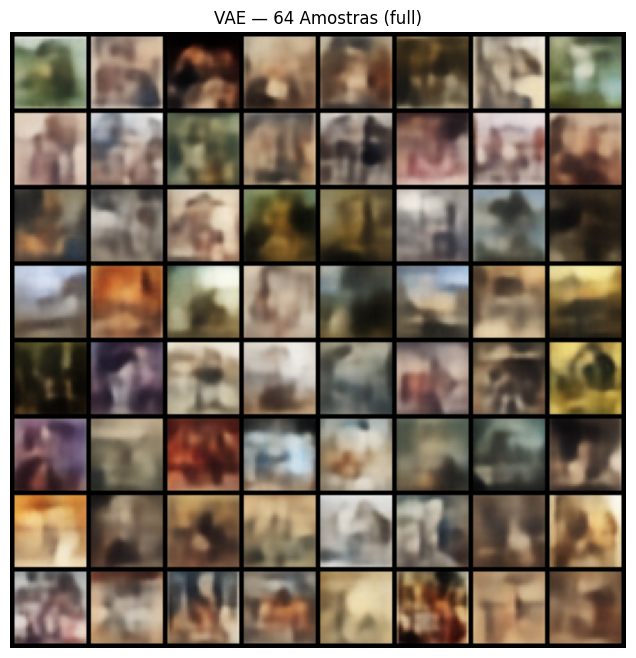

Guardado: amostras_vae_full.png
Gerando amostras GAN...


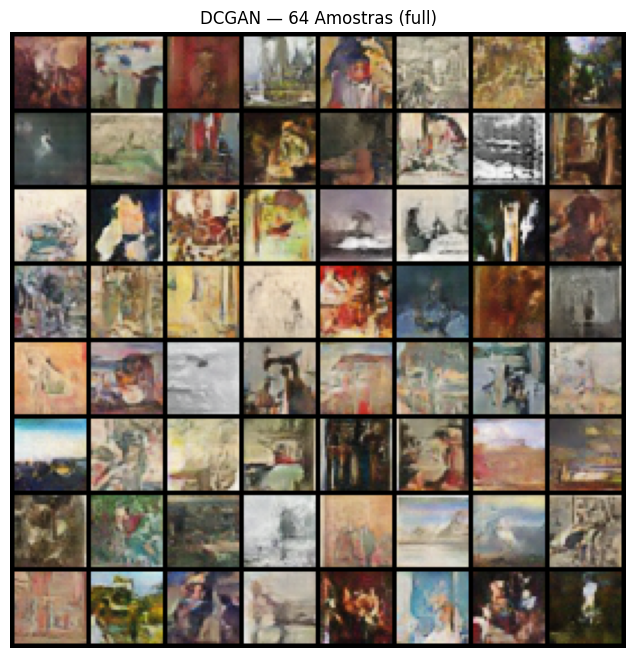

Guardado: amostras_gan_full.png
Gerando amostras Diffusion (DDIM 100 steps)...


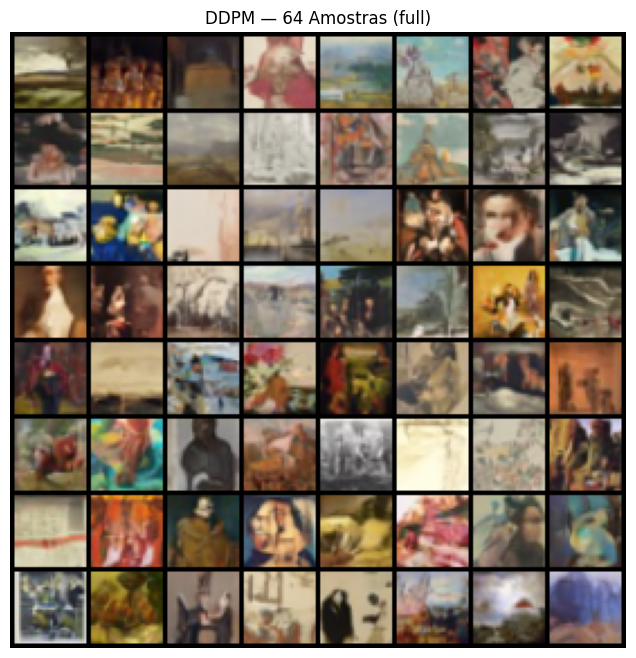

Guardado: amostras_diffusion_full.png


In [15]:
# ── Amostras visuais (64 por modelo) ────────────────────────────────
from torchvision.utils import make_grid

def show_and_save(imgs, title, filename, n=64):
    imgs = imgs[:n].cpu()
    grid = make_grid((imgs + 1) / 2, nrow=8, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
    plt.title(title); plt.axis('off')
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {filename}')

print('Gerando amostras VAE...')
vae_vis = generate_vae(64)
show_and_save(vae_vis, 'VAE — 64 Amostras (full)', 'amostras_vae_full.png')

print('Gerando amostras GAN...')
gan_vis = generate_gan(64)
show_and_save(gan_vis, 'DCGAN — 64 Amostras (full)', 'amostras_gan_full.png')

print('Gerando amostras Diffusion (DDIM 100 steps)...')
diff_vis = generate_diffusion_ddim(64)
show_and_save(diff_vis, 'DDPM — 64 Amostras (full)', 'amostras_diffusion_full.png')

In [16]:
# ── Avaliação quantitativa: 10 seeds ────────────────────────────────
N_SEEDS = 10

results = {
    'vae':       {'fid': [], 'kid_mean': [], 'kid_std': []},
    'gan':       {'fid': [], 'kid_mean': [], 'kid_std': []},
    'diffusion': {'fid': [], 'kid_mean': [], 'kid_std': []},
}

for seed_i in range(N_SEEDS):
    seed = 42 + seed_i
    print(f'\n{"="*60}')
    print(f'Seed {seed_i+1}/{N_SEEDS}  (seed={seed})')
    print(f'{"="*60}')

    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)

    print('  Carregando imagens reais...')
    real_imgs  = get_real_images(N_SAMPLES)
    real_01    = (real_imgs + 1) / 2
    real_feats = get_inception_features(real_01, batch_size=64)

    # VAE
    print('  Gerando VAE...')
    torch.manual_seed(seed)
    vae_imgs  = generate_vae(N_SAMPLES)
    vae_feats = get_inception_features((vae_imgs + 1) / 2, batch_size=64)
    fid_v = compute_fid(real_feats, vae_feats)
    kid_v_m, kid_v_s = compute_kid(real_feats, vae_feats)
    results['vae']['fid'].append(fid_v)
    results['vae']['kid_mean'].append(kid_v_m)
    results['vae']['kid_std'].append(kid_v_s)
    print(f'    VAE  → FID={fid_v:.2f} | KID={kid_v_m:.4f}±{kid_v_s:.4f}')
    del vae_imgs, vae_feats

    # GAN
    print('  Gerando GAN...')
    torch.manual_seed(seed)
    gan_imgs  = generate_gan(N_SAMPLES)
    gan_feats = get_inception_features((gan_imgs + 1) / 2, batch_size=64)
    fid_g = compute_fid(real_feats, gan_feats)
    kid_g_m, kid_g_s = compute_kid(real_feats, gan_feats)
    results['gan']['fid'].append(fid_g)
    results['gan']['kid_mean'].append(kid_g_m)
    results['gan']['kid_std'].append(kid_g_s)
    print(f'    GAN  → FID={fid_g:.2f} | KID={kid_g_m:.4f}±{kid_g_s:.4f}')
    del gan_imgs, gan_feats

    # DDPM (DDIM)
    print('  Gerando Diffusion (DDIM 100 steps)...')
    torch.manual_seed(seed)
    diff_imgs  = generate_diffusion_ddim(N_SAMPLES)
    diff_feats = get_inception_features((diff_imgs + 1) / 2, batch_size=64)
    fid_d = compute_fid(real_feats, diff_feats)
    kid_d_m, kid_d_s = compute_kid(real_feats, diff_feats)
    results['diffusion']['fid'].append(fid_d)
    results['diffusion']['kid_mean'].append(kid_d_m)
    results['diffusion']['kid_std'].append(kid_d_s)
    print(f'    DIFF → FID={fid_d:.2f} | KID={kid_d_m:.4f}±{kid_d_s:.4f}')
    del diff_imgs, diff_feats

    del real_imgs, real_01, real_feats
    torch.cuda.empty_cache()

print('\n✅ Avaliação completa!')


Seed 1/10  (seed=42)
  Carregando imagens reais...
  Gerando VAE...
  VAE: 500/5000
  VAE: 1000/5000
  VAE: 1500/5000
  VAE: 2000/5000
  VAE: 2500/5000
  VAE: 3000/5000
  VAE: 3500/5000
  VAE: 4000/5000
  VAE: 4500/5000
  VAE: 5000/5000


C:\Users\kicov\AppData\Local\Temp\ipykernel_3696\2187832546.py:24: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sig_r @ sig_f, disp=False)


    VAE  → FID=140.35 | KID=0.0314±0.0016
  Gerando GAN...
  GAN: 500/5000
  GAN: 1000/5000
  GAN: 1500/5000
  GAN: 2000/5000
  GAN: 2500/5000
  GAN: 3000/5000
  GAN: 3500/5000
  GAN: 4000/5000
  GAN: 4500/5000
  GAN: 5000/5000
    GAN  → FID=31.10 | KID=0.0032±0.0009
  Gerando Diffusion (DDIM 100 steps)...
  Diffusion DDIM: 500/5000
  Diffusion DDIM: 1000/5000
  Diffusion DDIM: 1500/5000
  Diffusion DDIM: 2000/5000
  Diffusion DDIM: 2500/5000
  Diffusion DDIM: 3000/5000
  Diffusion DDIM: 3500/5000
  Diffusion DDIM: 4000/5000
  Diffusion DDIM: 4500/5000
  Diffusion DDIM: 5000/5000
    DIFF → FID=37.94 | KID=0.0061±0.0008

Seed 2/10  (seed=43)
  Carregando imagens reais...
  Gerando VAE...
  VAE: 500/5000
  VAE: 1000/5000
  VAE: 1500/5000
  VAE: 2000/5000
  VAE: 2500/5000
  VAE: 3000/5000
  VAE: 3500/5000
  VAE: 4000/5000
  VAE: 4500/5000
  VAE: 5000/5000
    VAE  → FID=140.02 | KID=0.0313±0.0019
  Gerando GAN...
  GAN: 500/5000
  GAN: 1000/5000
  GAN: 1500/5000
  GAN: 2000/5000
  GAN: 

RuntimeError: CUDA error: CUBLAS_STATUS_ALLOC_FAILED when calling `cublasLtMatmulPreferenceCreate(&raw_descriptor)`

In [ ]:
# ── Tabela de resultados finais ──────────────────────────────────────
print(f"{'Modelo':<12} {'FID (média±std)':>22}   {'KID (média±std)':>22}")
print('─' * 60)
for name, label in [('vae','VAE'), ('gan','DCGAN'), ('diffusion','DDPM')]:
    fid_m = np.mean(results[name]['fid']);  fid_s = np.std(results[name]['fid'])
    kid_m = np.mean(results[name]['kid_mean']); kid_s = np.std(results[name]['kid_mean'])
    print(f"{label:<12} {fid_m:>8.2f} ± {fid_s:<8.2f}   {kid_m:>8.4f} ± {kid_s:<8.4f}")

print()
best_fid = min(['vae','gan','diffusion'], key=lambda k: np.mean(results[k]['fid']))
best_kid = min(['vae','gan','diffusion'], key=lambda k: np.mean(results[k]['kid_mean']))
print(f"Melhor FID: {best_fid.upper()}")
print(f"Melhor KID: {best_kid.upper()}")

In [ ]:
# ── Gráfico comparativo (igual ao 4b) ───────────────────────────────
models = ['VAE', 'DCGAN', 'DDPM']
keys   = ['vae', 'gan', 'diffusion']

fid_means = [np.mean(results[k]['fid']) for k in keys]
fid_stds  = [np.std(results[k]['fid'])  for k in keys]
kid_means = [np.mean(results[k]['kid_mean']) for k in keys]
kid_stds  = [np.std(results[k]['kid_mean'])  for k in keys]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']

ax1.bar(models, fid_means, yerr=fid_stds, capsize=5, color=colors, alpha=0.85)
ax1.set_ylabel('FID (↓ melhor)'); ax1.set_title('FID — Modelos (full dataset)')
ax1.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(fid_means, fid_stds)):
    ax1.text(i, m + s + 1, f'{m:.1f}', ha='center', fontsize=11, fontweight='bold')

ax2.bar(models, kid_means, yerr=kid_stds, capsize=5, color=colors, alpha=0.85)
ax2.set_ylabel('KID (↓ melhor)'); ax2.set_title('KID — Modelos (full dataset)')
ax2.grid(axis='y', alpha=0.3)
for i, (m, s) in enumerate(zip(kid_means, kid_stds)):
    ax2.text(i, m + s + 0.001, f'{m:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('comparacao_fid_kid_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: comparacao_fid_kid_full.png')

In [ ]:
# ── Tabela detalhada por seed ────────────────────────────────────────
print(f"{'Seed':<6} {'VAE FID':>10} {'GAN FID':>10} {'DIFF FID':>10}  │  {'VAE KID':>10} {'GAN KID':>10} {'DIFF KID':>10}")
print('─' * 80)
for i in range(N_SEEDS):
    seed = 42 + i
    print(f"{seed:<6} "
          f"{results['vae']['fid'][i]:>10.2f} "
          f"{results['gan']['fid'][i]:>10.2f} "
          f"{results['diffusion']['fid'][i]:>10.2f}  │  "
          f"{results['vae']['kid_mean'][i]:>10.4f} "
          f"{results['gan']['kid_mean'][i]:>10.4f} "
          f"{results['diffusion']['kid_mean'][i]:>10.4f}")